# 📊 FinDataMining
Notebook 03: **Modelado**

---

## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import shap
import matplotlib.pyplot as plt
from src.transform import obtener_cols_financieras, obtener_cols_flag
from src.config import clean_data_file, reports_folder
from src.modeling import *

In [2]:
# Abrir archivo clean_data
df = pd.read_parquet(clean_data_file)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31772 entries, 4 to 35309
Data columns (total 76 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   CashAndCashEquivalents                 31772 non-null  float64       
 1   CurrentDebt                            31772 non-null  float64       
 2   LongTermDebt                           31772 non-null  float64       
 3   TotalDebt                              31772 non-null  float64       
 4   StockholdersEquity                     31772 non-null  float64       
 5   TotalAssets                            31772 non-null  float64       
 6   CurrentAssets                          31772 non-null  float64       
 7   CurrentLiabilities                     31772 non-null  float64       
 8   TotalNoncurrentLiabilities             31772 non-null  float64       
 9   TotalLiabilities                       31772 non-null  float64    

## Feature Engineering

In [3]:
# Celda reservada para probar la creación de variables en la fase de modelado.

# Crear label binaria: para simplificar la clasificación, 1 si es el Quintil 5
df['Target_Top_Quintile'] = np.where(df['MonthlyExcessReturn_Quantile'] == 5, 1, 0)


## Modelo de ensamblado de árboles RandomForest

In [48]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras()

# Columnas flag: las quito por su baja relevancia
cols_flag = obtener_cols_flag(df)

# Excluir las variables que tengan baja importancia para reducir el ruido
variables_no_significativas = [
    'AverageDailyVolume_Lag1_YoY_Yeo',
    'FreeCashFlow_TTM_QoQ',
    'CapitalExpenditure_TTM_QoQ',
    'AverageDailyVolume_Lag1_Acceleration',
    'CapitalExpenditure_TTM_YoY',
    'CurrentRatio_Log1p'
]

predictores_a_eliminar = cols_financieras + cols_flag + variables_no_significativas + [
    # Variable objetivo
    'MonthlyExcessReturn_Quantile',
    'Target_Top_Quintile',

    # Variables de volumen y precios crudos: 
    # No tiene sentido utilizarlas habiendo multiples tickers
    'Open',
    'Close',    
    'AverageDailyVolume_Lag1',

    # Otros
    'Ticker',
    'Date',
    'FinancialsSource'
    ]

# Se define la variable objetivo (categórica)
label = 'Target_Top_Quintile'

# Se separan los datos pasados de los del mes actual
# X_train / y_train: Todos los meses históricos completamente cerrados
# X_live / _ : El mes actual en curso (y_test se ignora porque es inválido)
X_train, X_live, y_train, _ = split_ultimo(df, label=label, cols_excluded=predictores_a_eliminar)

# Columnas numéricas: 
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

# Reemplazo de RandomForestRegressor por RandomForestClassifier
pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_estimators=400,
        max_depth=3,
        min_samples_leaf=50,
        min_samples_split= 100,
        max_samples= 0.5,
        max_features=0.1,
        class_weight='balanced'        
        ))
])

print("Entrenando el modelo clasificador con datos históricos completos...")
pipe.fit(X_train, y_train)
accuracy_completa = pipe.score(X_train, y_train)
print(f"Entrenamiento finalizado. Precision en histórico: {accuracy_completa:.4f}")

Entrenando el modelo clasificador con datos históricos completos...
Entrenamiento finalizado. Precision en histórico: 0.6032


In [49]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X_train, 
    y=y_train, 
    cv=tscv,         
    scoring='precision',
    n_jobs=-1        
)

print(f"Precision promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

Precision promedio Time Series CV: 0.2484 ± 0.0156


In [50]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(25)

,feature,importance
29,cat__Industry,0.213220
21,num__ProfitMargins_Yeo,0.062919
12,num__MarketCap_Log1p,0.057988
10,num__ShortTermBeta,0.056674
27,num__EarningsYield_Yeo,0.056524
20,num__OperatingMargins_Yeo,0.043774
24,num__EnterpriseValue_Yeo,0.041552
2,num__RevenueYield,0.038237
23,num__ReturnOnEquity_Yeo,0.036448
22,num__ReturnOnAssets_Yeo,0.034782


In [51]:
# Variables menos significativas
feature_importance_df.tail(20)

,feature,importance
19,num__EBITDA_TTM_YoY_Yeo,0.034418
0,num__YearsSinceAdded,0.032056
7,num__EBITDA_TTM_Acceleration,0.031955
3,num__AssetToMarket,0.030586
18,num__EBITDA_TTM_QoQ_Yeo,0.027001
16,num__TotalRevenue_TTM_YoY_Yeo,0.021623
1,num__EbitdaYield,0.021462
28,cat__Sector,0.019400
14,num__TotalRevenue_TTM_QoQ_Yeo,0.018751
6,num__TotalRevenue_TTM_Acceleration,0.018018


In [52]:
# Visualizar distribución de features
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,31287.0,14.446224,19.970516,0.000000,0.000000,5.000000,23.000000,69.000000
EbitdaYield,31287.0,0.080417,0.104244,-1.293643,0.044500,0.067785,0.103170,1.391318
RevenueYield,31287.0,0.773299,0.890849,-2.000000,0.232436,0.477080,0.955391,7.500000
AssetToMarket,31287.0,1.461387,1.588102,0.001536,0.496643,0.925345,1.773950,15.406201
NetDebtToEbitda,31287.0,2.479837,3.735634,-16.248426,0.669731,1.992038,3.773625,20.958458
FreeCashFlow_TTM_YoY,31287.0,0.252938,1.312374,-4.470731,-0.258343,0.030000,0.425268,4.620476
TotalRevenue_TTM_Acceleration,31287.0,-0.065578,0.179854,-1.366291,-0.099128,-0.037115,0.007447,1.310585
EBITDA_TTM_Acceleration,31287.0,-0.146971,0.674129,-3.454371,-0.230207,-0.053755,0.064957,3.353244
FreeCashFlow_TTM_Acceleration,31287.0,-0.225268,2.121225,-8.689418,-0.403533,-0.030000,0.230565,8.343722
CapitalExpenditure_TTM_Acceleration,31287.0,0.133346,0.724623,-3.570059,-0.100210,0.039730,0.263370,3.664040


## Aplicación del modelo

In [53]:
# Predicciones de la clase (Quintil 1 al 5)
y_pred_class = pipe.predict(X_live)

# Predicciones de probabilidad para desempatar y rankear
y_pred_proba = pipe.predict_proba(X_live)

# Extraer el modelo final del pipeline para conocer el orden de las clases
rf_model = pipe.named_steps['model']

# Identificar el índice de la columna que contiene la probabilidad de la clase 1 (Top Quintile)
idx_top = list(rf_model.classes_).index(1)
proba_top = y_pred_proba[:, idx_top]

# Recuperar los Tickers correspondientes a X_live
tickers_test = df.loc[X_live.index, 'Ticker']

# Construir el DataFrame de resultados
resultados_agrupados = pd.DataFrame({
    'Ticker': tickers_test.values,
    'Predicted_Class': y_pred_class,
    'Probability_Top': proba_top
})

# Generar la señal
resultados_agrupados['Signal'] = np.where(
    resultados_agrupados['Predicted_Class'] == 1, 'Buy_Candidate', 'Neutral'
)

# Ordenar resultados por la probabilidad de ser Top Quintil
resultados_agrupados = resultados_agrupados.sort_values(by='Probability_Top', ascending=False)

print(resultados_agrupados.head(10).to_string(index=False))

Ticker  Predicted_Class  Probability_Top        Signal
   ADV                1         0.629610 Buy_Candidate
    MU                1         0.611399 Buy_Candidate
    GO                1         0.610990 Buy_Candidate
   WDC                1         0.610529 Buy_Candidate
   AMN                1         0.608797 Buy_Candidate
  JELD                1         0.597396 Buy_Candidate
   XRX                1         0.595828 Buy_Candidate
   RIG                1         0.592003 Buy_Candidate
  CNDT                1         0.591484 Buy_Candidate
  INTC                1         0.590759 Buy_Candidate


In [54]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

# Crear carpeta si no existe y nombrar el archivo con la fecha
reports_folder.mkdir(parents=True, exist_ok=True)
nombre_archivo = f"{year}_{mes}_{dia}.csv"
ruta_completa = reports_folder / nombre_archivo

df_reporte.to_csv(ruta_completa, index=False)
print(f'Reporte exportado en la carpeta de datos.')
df_reporte.head()

Reporte exportado en la carpeta de datos.


,Ticker,Predicted_Class,Probability_Top,Signal,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,StockholdersEquity,TotalAssets,...,EBITDA_TTM_YoY_Yeo,OperatingMargins_Yeo,ProfitMargins_Yeo,ReturnOnAssets_Yeo,ReturnOnEquity_Yeo,EnterpriseValue_Yeo,CapExToRevenue_Log1p,BookToMarket_Yeo,EarningsYield_Yeo,Target_Top_Quintile
0,ADV,1,0.629610,Buy_Candidate,143.870,25.865,1520.790,1546.655,478.028,2564.850,...,-0.732730,-0.866193,-0.996752,-1.588005,-0.110566,-0.433032,0.013612,1.180872,-3.073379,0
1,MU,1,0.611399,Buy_Candidate,24995.000,3324.000,3052.000,6376.000,100724.000,134112.000,...,2.519300,4.024068,3.443671,3.753116,0.029202,2.535861,0.242891,-1.118947,-0.039737,0
2,GO,1,0.610990,Buy_Candidate,58.998,15.000,474.254,1841.770,807.096,2958.009,...,-2.330782,-0.835101,-1.061953,-1.861779,-0.106080,-0.421573,0.043816,1.105381,-2.837962,1
3,WDC,1,0.610529,Buy_Candidate,2050.000,1581.000,2429.000,1581.000,9680.000,15045.000,...,1.787098,1.173174,3.405966,4.067148,0.055543,0.775501,0.031839,-1.310353,-0.124590,0
4,AMN,1,0.608797,Buy_Candidate,560.738,34.426,742.491,776.917,712.806,2604.373,...,-0.362957,-0.698435,-0.686878,-0.851137,-0.050361,-0.440410,0.009576,0.575514,-0.580305,1


## Explicabilidad del Modelo (SHAP)

In [58]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'ADV'

--- Explicación de la probabilidad de ser Quintil 5 para: ADV ---


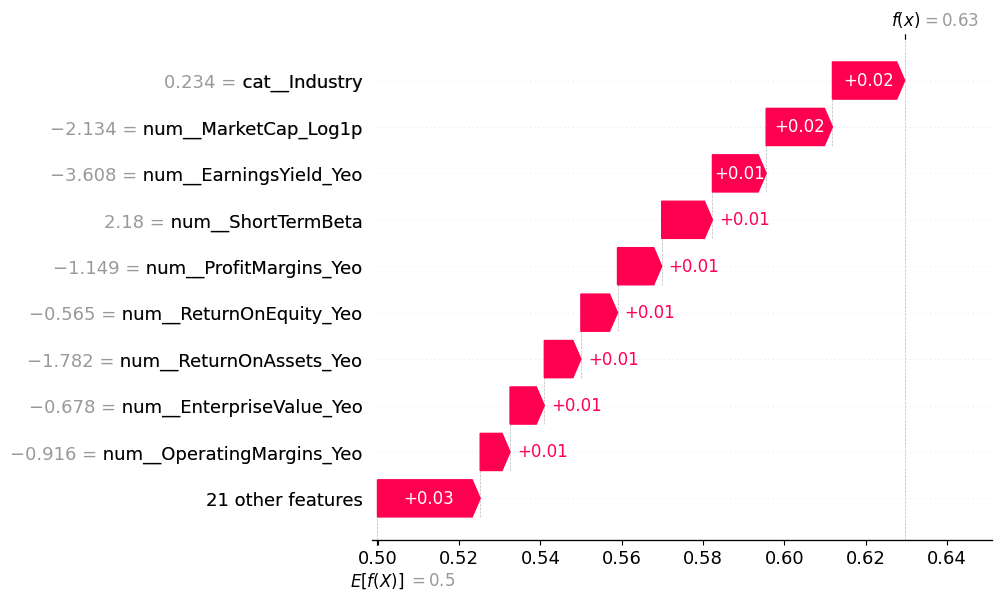

In [59]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_live)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_live.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test.values == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP
    shap_values = explainer(X_ticker_eval)
    
    # Seleccionar la explicación específica para la clase 1 (Top Quintile)
    idx_top = list(rf_model.classes_).index(1)
    shap_values_q5 = shap_values[..., idx_top]
    
    print(f"--- Explicación de la probabilidad de ser Quintil 5 para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada
    shap.plots.waterfall(shap_values_q5[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiper-parámetros

In [ ]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest Classifier"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el clasificador
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestClassifier(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [400],
        'rf__max_depth': [3],
        'rf__min_samples_leaf': [40],
        'rf__min_samples_split': [80],
        'rf__max_samples': [0.5],
        'rf__max_features': [0.1]
    }

    # Configurar el GridSearchCV con la métrica correcta
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='precision',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X_train, y_train)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)

Configurando GridSearchCV para Random Forest Classifier
Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.
Fitting 5 folds for each of 1 candidates, totalling 5 fits

--- Búsqueda Finalizada ---
Mejores hiperparámetros encontrados:
{'rf__max_depth': 3, 'rf__max_features': 0.1, 'rf__max_samples': 0.5, 'rf__min_samples_leaf': 40, 'rf__min_samples_split': 80, 'rf__n_estimators': 400}
